## Load and prepare final dataframe for model

In [1]:
# Load df_artists and df_songs from CSV with all columns visible in head/sample output.

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df_artists = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists.csv')

print(df_artists.shape)

# Load df_songs from CSV.

df_songs = pd.read_csv('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_songs.csv')

print(df_songs.shape)

(13655, 44)
(38383, 43)


In [21]:
df_artists.head()

,name,musicbrainz_artist_id,musicbrainz_mbid,spotify_id,performer_pre_normalized,first_top_20_hit_year,first_charting_song_year,last_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,first_song_year,years_active_on_charts,first_charting_song_position,first_charting_song_duration,top_20_hit_song_#_wks_on_chart_any_position,genre_tags_musicbrainz,first_year_on_chart_songs,genre_tags_through_first_top_10_hit,major_genre_categories_through_first_top_10_hit,#_of_major_genre_categories_through_first_top_10_hit,musicbrainz_major_genre_categories,musicbrainz_#_of_genres,spotify_genres,spotify_major_genre_categories,combined_major_genre_categories,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,!!! (chk chk chk),NaN,NaN,NaN,!!! (Chk Chk Chk),NaN,NaN,NaN,NaN,NaN,NaN,2007-2007,0,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"""groove"" holmes",NaN,NaN,NaN,"""Groove"" Holmes",NaN,1966.0,1966.0,NaN,NaN,1966.0,1966-1966,44,11,NaN,NaN,1966.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"""little"" jimmy dickens",NaN,NaN,NaN,"""Little"" Jimmy Dickens",1965.0,1965.0,1965.0,1.0,1.0,1965.0,1965-1965,15,10,NaN,NaN,1965.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,"""pookie"" hudson",232958.0,29dc9009-015f-47c4-bd17-ed2af6d2ae0c,NaN,"""Pookie"" Hudson",NaN,1963.0,1963.0,NaN,NaN,1963.0,1963-1963,96,1,NaN,NaN,1963.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"""weird al"" yankovic",NaN,NaN,NaN,"""Weird Al"" Yankovic",1984.0,1983.0,2014.0,2.0,4.0,1983.0,1983-2014,63,8,NaN,NaN,1983.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [2]:
# Create df_artists_final from df_artists:
# - drops non-feature/identifier columns
# - filters to artists whose first top-20 hit was between 2000 and 2019
# - keeps combined_major_genre_categories, renamed to combined_major_genre_categories_artist

cols_to_drop = [
    'musicbrainz_artist_id', 'musicbrainz_mbid', 'spotify_id',
    'performer_pre_normalized', 'last_charting_song_year', 'first_song_year',
    'years_active_on_charts', 'first_charting_song_position',
    'first_charting_song_duration', 'genre_tags_musicbrainz',
    'first_year_on_chart_songs', 'genre_tags_through_first_top_10_hit',
    'major_genre_categories_through_first_top_10_hit',
    '#_of_major_genre_categories_through_first_top_10_hit',
    'musicbrainz_major_genre_categories', 'musicbrainz_#_of_genres',
    'spotify_genres', 'spotify_major_genre_categories',
]

df_artists_final = (
    df_artists[df_artists['first_top_20_hit_year'].between(2000, 2019)]
    .drop(columns=[c for c in cols_to_drop if c in df_artists.columns])
    .rename(columns={'combined_major_genre_categories': 'combined_major_genre_categories_artist'})
    .reset_index(drop=True)
)

print(df_artists_final.shape)
df_artists_final.head()


(778, 26)


,name,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,combined_major_genre_categories_artist,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,first_top_20_song_explicit,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker
0,2 chainz,2012.0,2012.0,1.0,9.0,27.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0
1,21 savage,2017.0,2016.0,2.0,15.0,41.0,Hip Hop/Rap,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0
2,3 doors down,2000.0,2000.0,1.0,2.0,53.0,"Metal, Pop, Rock","Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0
3,3oh!3,2008.0,2008.0,1.0,1.0,37.0,"Electronic/Dance, Hip Hop/Rap, Pop, Punk/Hardc...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,5 seconds of summer,2014.0,2014.0,1.0,6.0,20.0,"Pop, Punk/Hardcore",Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.0,0.000048,1.000000,0.000000,1.555431e-18,NaN,1.0


#### *Don't run both of the next 2 cells. Choose one. The first cell one-hot-encodes the artist genre data and the second cell one-hot-encodes the song genre data. The former has fewer null values.*

In [3]:
# One-hot encode combined_major_genre_categories_artist into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'artist_genre_', replacing the original column.

artist_genre_dummies = (
    df_artists_final['combined_major_genre_categories_artist']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='artist_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
artist_genre_dummies = artist_genre_dummies.loc[:, artist_genre_dummies.columns != 'artist_genre_']

# Insert genre columns where combined_major_genre_categories_artist was, then drop original
insert_at = df_artists_final.columns.get_loc('combined_major_genre_categories_artist')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    artist_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

# Add binary flag for artists with no genre data — inserted after last genre column
all_genre_cols = [c for c in df_artists_final.columns if c.startswith(('artist_genre_', 'song_genre_'))]
last_genre_idx = df_artists_final.columns.get_loc(all_genre_cols[-1])
df_artists_final.insert(last_genre_idx + 1, 'artist_genre_unknown', (df_artists_final[all_genre_cols].sum(axis=1) == 0).astype(int))

print("Artist genre columns added:", artist_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


Artist genre columns added: ['artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music']
df_artists_final shape: (778, 44)


In [ ]:
# One-hot encode first_top_20_song_major_genres into binary columns in df_artists_final.
# Splits comma-separated genre strings, creates one binary column per genre,
# prefixed with 'song_genre_', replacing the original column.
# Also adds song_genre_unknown flag for artists with no song genre data.

song_genre_dummies = (
    df_artists_final['first_top_20_song_major_genres']
    .fillna('')
    .str.split(', ')
    .explode()
    .str.strip()
    .pipe(lambda s: pd.get_dummies(s, prefix='song_genre'))
    .groupby(level=0)
    .max()
)

# Remove the empty-string column if it exists (from NaN rows)
song_genre_dummies = song_genre_dummies.loc[:, song_genre_dummies.columns != 'song_genre_']

# Add song_genre_unknown flag to dummies before inserting
song_genre_dummies['song_genre_unknown'] = (song_genre_dummies.sum(axis=1) == 0).astype(int)

# Insert genre columns where first_top_20_song_major_genres was, then drop original
insert_at = df_artists_final.columns.get_loc('first_top_20_song_major_genres')
df_artists_final = pd.concat([
    df_artists_final.iloc[:, :insert_at],
    song_genre_dummies,
    df_artists_final.iloc[:, insert_at + 1:]
], axis=1)

print("Song genre columns added:", song_genre_dummies.columns.tolist())
print("df_artists_final shape:", df_artists_final.shape)


In [4]:
# Drop rows with null top_20_hitmaker (artists with no verified top-20 songs)
# and any duplicate rows, then confirm shape and class balance.

df_artists_final = (
    df_artists_final
    .dropna(subset=['top_20_hitmaker'])
    .drop_duplicates()
    .reset_index(drop=True)
)

print(df_artists_final.shape)
print()
print(df_artists_final['top_20_hitmaker'].value_counts())


(759, 44)

top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64


In [5]:
# Drop name column, cast bool genre columns to int (0/1) in df_artists_final.

genre_cols = [c for c in df_artists_final.columns if c.startswith('genre_')]

df_artists_final = df_artists_final.drop(columns=['name'])
df_artists_final[genre_cols] = df_artists_final[genre_cols].astype(int)

print(df_artists_final.shape)
print(df_artists_final[genre_cols].dtypes.unique())


(759, 43)
[]


#### *Avoiding imputing median values for weeks on chart and spotify audio features in the next cell--this notebook is just for multicollinearity analysis*

In [6]:
# Impute missing values in df_artists_final (for multicollinearity analysis):
# - Network metrics → fill with 0 (no collaboration data = no centrality)
# - Weeks on chart and Spotify audio features → left as null for honest VIF analysis

network_metric_cols = [
    'degree_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'power_of_connected_artists_top20_rolling5',
]
for col in network_metric_cols:
    if col in df_artists_final.columns:
        df_artists_final[col] = df_artists_final[col].fillna(0)

# Add has_spotify_data flag but do not impute spotify features
spotify_cols = [
    c for c in df_artists_final.columns
    if c.startswith('first_top_20_song_')
    and c not in {'first_top_20_song_explicit', 'first_top_20_song_major_genres'}
]
has_spotify = df_artists_final[spotify_cols].notna().any(axis=1).astype(int)
insert_at = df_artists_final.columns.get_loc('first_top_20_song_mode') + 1
df_artists_final.insert(insert_at, 'has_spotify_data', has_spotify)

if 'first_top_20_song_explicit' in df_artists_final.columns:
    df_artists_final = df_artists_final.drop(columns=['first_top_20_song_explicit'])

print("Imputation complete (network metrics only).")
print(df_artists_final.isnull().sum()[df_artists_final.isnull().sum() > 0])


Imputation complete (network metrics only).
top_20_hit_song_#_wks_on_chart_any_position     87
first_top_20_song_major_genres                 391
first_top_20_song_duration_ms                  326
first_top_20_song_acousticness                 326
first_top_20_song_danceability                 326
first_top_20_song_energy                       326
first_top_20_song_instrumentalness             326
first_top_20_song_liveness                     326
first_top_20_song_loudness                     326
first_top_20_song_speechiness                  326
first_top_20_song_tempo                        326
first_top_20_song_valence                      326
first_top_20_song_mode                         326
dtype: int64


In [7]:
# Fill null network metric columns with 0 (no collaboration data = no centrality)
network_cols = [
    'degree_centrality_top20_rolling5',
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5',
    'power_of_connected_artists_top20_rolling5',
]
df_artists_final[network_cols] = df_artists_final[network_cols].fillna(0)
print(df_artists_final[network_cols].isnull().sum())


degree_centrality_top20_rolling5                0
harmonic_closeness_centrality_top20_rolling5    0
betweenness_centrality_top20_rolling5           0
eigenvector_centrality_top20_rolling5           0
power_of_connected_artists_top20_rolling5       0
dtype: int64


In [11]:
df_artists_final.head()

,first_top_20_hit_year,first_charting_song_year,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,first_top_20_song_major_genres,first_top_20_song_duration_ms,first_top_20_song_acousticness,first_top_20_song_danceability,first_top_20_song_energy,first_top_20_song_instrumentalness,first_top_20_song_liveness,first_top_20_song_loudness,first_top_20_song_speechiness,first_top_20_song_tempo,first_top_20_song_valence,first_top_20_song_mode,degree_centrality_top20_rolling5,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,power_of_connected_artists_top20_rolling5,top_20_hitmaker,has_spotify_data
0,2012.0,2012.0,1.0,9.0,27.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,NaN,228000.0,0.06690,0.662,0.720,0.000000,0.121,-5.428,0.0556,119.987,0.527,1.0,0.006764,5314.363492,0.010130,1.510211e-01,7104.5,1.0,0
1,2017.0,2016.0,2.0,15.0,41.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,NaN,228000.0,0.06690,0.662,0.720,0.000000,0.121,-5.428,0.0556,119.987,0.527,1.0,0.002871,5233.436039,0.001326,7.977090e-02,3116.5,1.0,0
2,2000.0,2000.0,1.0,2.0,53.0,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,0,"Blues, Metal, Rock",233933.0,0.00664,0.545,0.865,0.000011,0.168,-5.708,0.0286,99.009,0.543,0.0,0.000000,0.000000,0.000000,0.000000e+00,0.0,1.0,1
3,2008.0,2008.0,1.0,1.0,37.0,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,True,False,0,NaN,228000.0,0.06690,0.662,0.720,0.000000,0.121,-5.428,0.0556,119.987,0.527,1.0,0.000000,0.000000,0.000000,0.000000e+00,0.0,1.0,0
4,2014.0,2014.0,1.0,6.0,20.0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,0,Pop,237248.0,0.02830,0.572,0.499,0.000000,0.213,-5.237,0.0311,101.593,0.108,1.0,0.000048,1.000000,0.000000,1.555431e-18,0.0,1.0,1


### Multicollinearity analysis

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                                         Feature        VIF
0                          first_top_20_hit_year        inf
1                       first_charting_song_year        inf
2                 years_through_first_top_20_hit        inf
3      power_of_connected_artists_top20_rolling5  10.035423
4               degree_centrality_top20_rolling5   8.117273
5          eigenvector_centrality_top20_rolling5   5.303397
6          betweenness_centrality_top20_rolling5   3.913708
7                       first_top_20_song_energy   3.690306
8   harmonic_closeness_centrality_top20_rolling5   2.580705
9                     first_top_20_song_loudness   2.523156
10                      artist_genre_Hip Hop/Rap   2.231887
11                              artist_genre_Pop   1.952992
12                     first_top_20_song_valence   1.843180
13                first_top_20_song_danceability   1.731800
14                artist_genre_Country/Americana   1.712546
15                             artist_ge

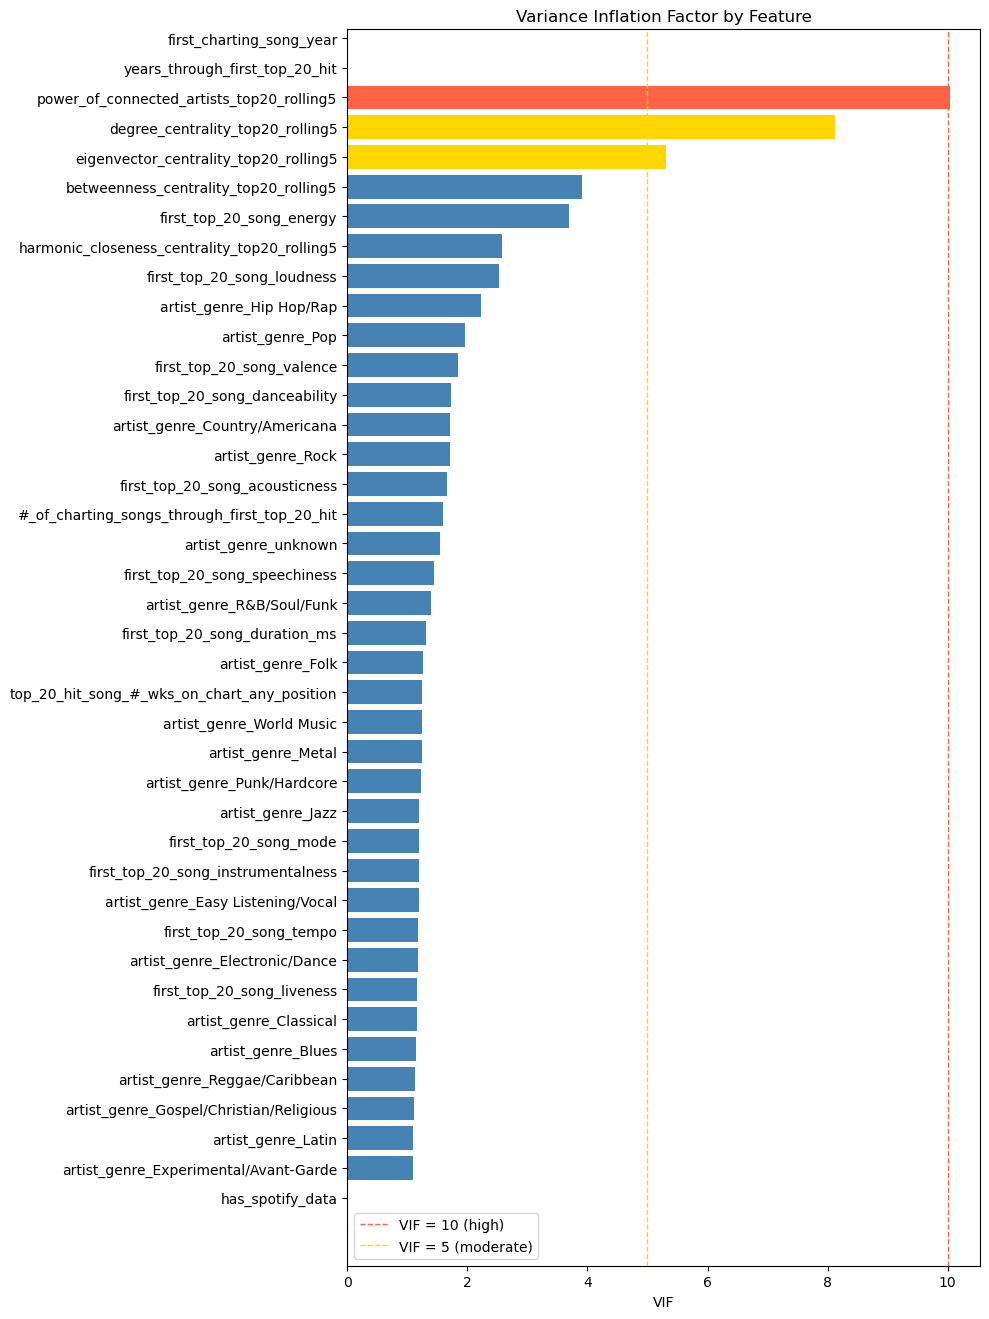

In [8]:
# Compute VIF for all features and visualize
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

X_vif = df_artists_final.drop(columns=['top_20_hitmaker'])
X_vif = (X_vif
    .apply(pd.to_numeric, errors='coerce')
    .dropna(axis=1, how='all')
    .dropna(axis=0)
    .astype(float)
)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, len(vif_data) * 0.3 + 1))
colors = ['tomato' if v > 10 else 'gold' if v > 5 else 'steelblue' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1], color=colors[::-1])
ax.axvline(10, color='tomato', linestyle='--', linewidth=1, label='VIF = 10 (high)')
ax.axvline(5, color='gold', linestyle='--', linewidth=1, label='VIF = 5 (moderate)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Feature')
ax.legend()
plt.tight_layout()
plt.show()


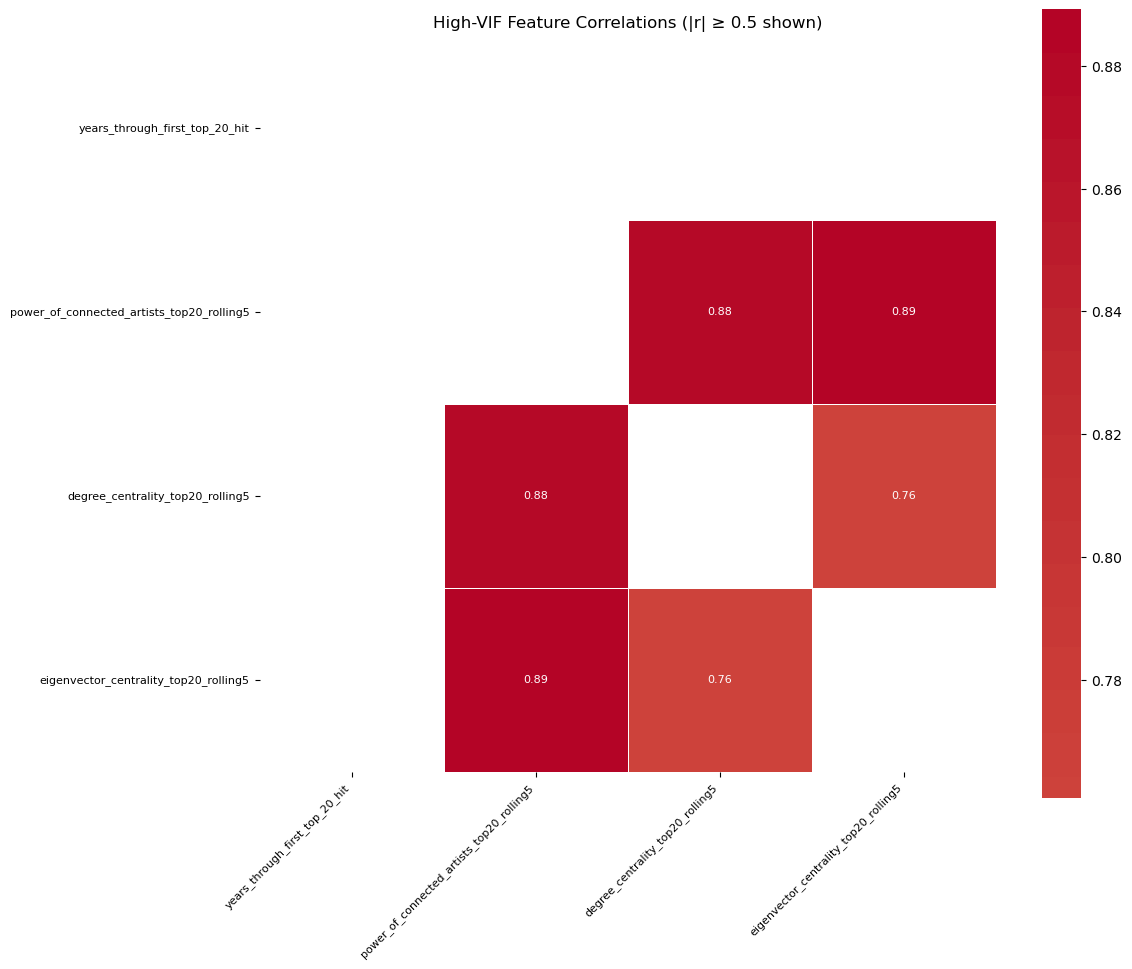

In [10]:
# Show pairwise correlations for high-VIF features — only show correlations above threshold
# Excludes first_top_20_hit_year and first_charting_song_year (not in final model)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

exclude_from_vif = {'first_top_20_hit_year', 'first_charting_song_year'}
high_vif_features = [f for f in vif_data.loc[vif_data['VIF'] > 5, 'Feature'].tolist()
                     if f not in exclude_from_vif]

corr = df_artists_final[high_vif_features].apply(pd.to_numeric, errors='coerce').corr()

# Mask the diagonal and low correlations
mask = np.abs(corr) < 0.5
np.fill_diagonal(mask.values, True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('High-VIF Feature Correlations (|r| ≥ 0.5 shown)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


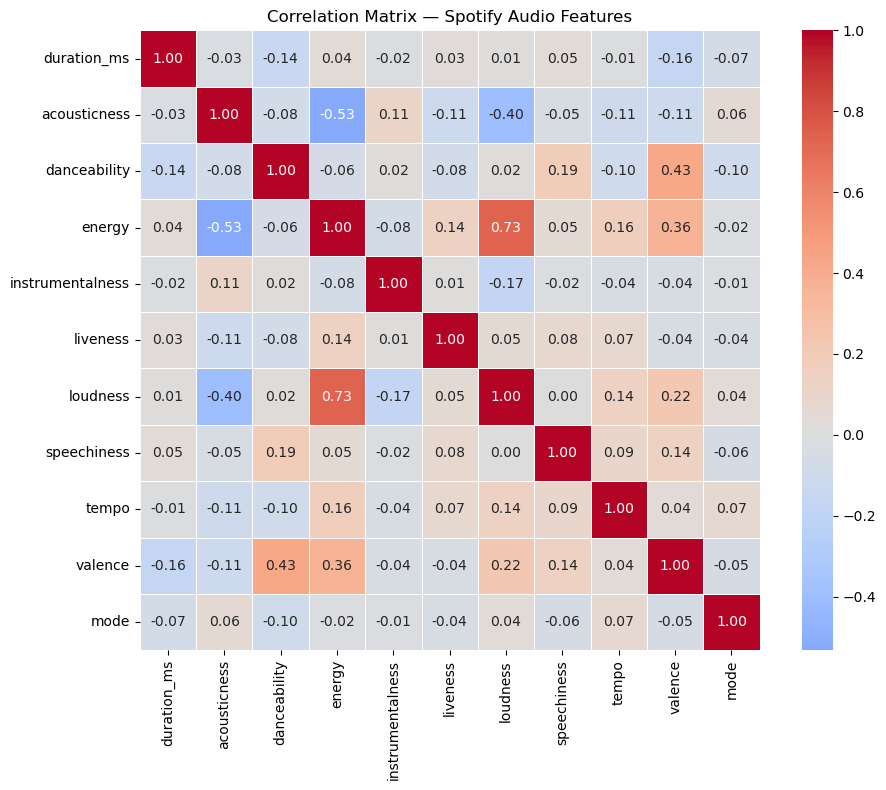

In [11]:
# Correlation matrix for Spotify audio features
import matplotlib.pyplot as plt
import seaborn as sns

spotify_cols = [c for c in df_artists_final.columns if c.startswith('first_top_20_song_')
                and c not in {'first_top_20_song_major_genres', 'first_top_20_song_explicit'}]

corr = df_artists_final[spotify_cols].corr()

# Shorten labels for readability
labels = [c.replace('first_top_20_song_', '') for c in spotify_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=labels, yticklabels=labels,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Spotify Audio Features')
plt.tight_layout()
plt.show()
